# Customer Churn Prediction — Step 8: Model Interpretation and Final Model Selection

**Input:** `data/trained_models.pkl` — four fitted scikit-learn `Pipeline` objects from Step 6  
**Input:** `data/preprocessed_splits.pkl` — `X_train`, `X_test`, `y_train`, `y_test` from Step 5  
**Output:** `models/final_churn_model.joblib` — the selected final pipeline  

### What this notebook does
1. Reconstructs the Step 7 evaluation metrics from the test set.
2. Interprets the Logistic Regression model via signed coefficients.
3. Interprets Random Forest and Gradient Boosting via feature importances.
4. Cross-compares feature signals across models.
5. Establishes documented selection criteria and selects the final model.
6. Saves the final pipeline to `models/final_churn_model.joblib`.

### What this notebook does NOT do
- Does **not** retrain any model.
- Does **not** modify `X_test` or `y_test`.
- Does **not** claim that feature importance or coefficients prove causation.
- Does **not** claim the selected model is universally optimal.

---

## 1. Setup — Imports and Load Artifacts

We import everything needed for interpretation and reload both pkl files from Steps 5 and 6.  
A fallback rebuild is included so the notebook is self-contained.

In [1]:
import os
import copy
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

RANDOM_STATE = 42
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == 'notebook' else NOTEBOOK_DIR
SPLITS_PATH  = os.path.join(PROJECT_ROOT, 'data', 'preprocessed_splits.pkl')
MODELS_PATH  = os.path.join(PROJECT_ROOT, 'data', 'trained_models.pkl')
CLEAN_PATH   = os.path.join(PROJECT_ROOT, 'data', 'telco_churn_cleaned.csv')
FINAL_DIR    = os.path.join(PROJECT_ROOT, 'models')
FINAL_PATH   = os.path.join(FINAL_DIR, 'final_churn_model.joblib')

os.makedirs(FINAL_DIR, exist_ok=True)

print('Splits pkl  :', os.path.exists(SPLITS_PATH))
print('Models pkl  :', os.path.exists(MODELS_PATH))
print('Output dir  :', FINAL_DIR)

Splits pkl  : True
Models pkl  : True
Output dir  : C:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\models


In [2]:
# ── Helper: rebuild preprocessor (identical to Steps 5–7) ────────────────────
def _build_preprocessor(num_feats, cat_feats):
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler',  StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer(
        transformers=[('num', num_pipe, num_feats), ('cat', cat_pipe, cat_feats)],
        remainder='drop'
    )


# ── Load splits ───────────────────────────────────────────────────────────────
if os.path.exists(SPLITS_PATH):
    splits = joblib.load(SPLITS_PATH)
    X_train = splits['X_train']
    X_test  = splits['X_test']
    y_train = splits['y_train']
    y_test  = splits['y_test']
    numerical_features   = splits['numerical_features']
    categorical_features = splits['categorical_features']
    print('Splits loaded from pkl.')
else:
    print('WARNING: splits pkl missing — rebuilding from CSV.')
    df = pd.read_csv(CLEAN_PATH)
    X  = df.drop(columns=['Churn'])
    y  = (df['Churn'] == 'Yes').astype(int)
    numerical_features   = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
    categorical_features = [c for c in X.columns if c not in numerical_features]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# ── Load trained models ───────────────────────────────────────────────────────
if os.path.exists(MODELS_PATH):
    artifacts = joblib.load(MODELS_PATH)
    trained_models    = artifacts['trained_models']
    all_feature_names = artifacts['all_feature_names']
    print('Trained models loaded from pkl.')
else:
    print('WARNING: models pkl missing — retraining (run Step 6 to avoid this).')
    preprocessor = _build_preprocessor(numerical_features, categorical_features)
    trained_models = {}
    for name, clf in [
        ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000,
            class_weight='balanced', random_state=RANDOM_STATE, solver='lbfgs')),
        ('Decision Tree', DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
            class_weight='balanced', random_state=RANDOM_STATE)),
        ('Random Forest', RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
            class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)),
        ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200,
            learning_rate=0.1, max_depth=4, subsample=0.8, random_state=RANDOM_STATE)),
    ]:
        pipe = Pipeline([('preprocessor', copy.deepcopy(preprocessor)), ('classifier', clf)])
        pipe.fit(X_train, y_train)
        trained_models[name] = pipe
    fitted_ct = trained_models['Random Forest'].named_steps['preprocessor']
    ohe = fitted_ct.named_transformers_['cat'].named_steps['encoder']
    all_feature_names = numerical_features + ohe.get_feature_names_out(categorical_features).tolist()

print()
print('Models:', list(trained_models.keys()))
print('X_test :', X_test.shape, '| y_test:', y_test.value_counts().sort_index().to_dict())
print('Feature names:', len(all_feature_names))

Splits loaded from pkl.
Trained models loaded from pkl.

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
X_test : (1405, 19) | y_test: {0: 1033, 1: 372}
Feature names: 45


---
## 2. Reconstruct Evaluation Metrics from Step 7

We recompute all five test-set metrics from the loaded (unmodified) trained pipelines and the untouched `X_test` / `y_test`.  
These values serve as the objective evidence base for the final model selection decision in Section 6.

In [3]:
eval_rows = []
for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    eval_rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    })

results_df = (
    pd.DataFrame(eval_rows)
    .set_index('Model')
    .sort_values('ROC-AUC', ascending=False)
)

print('=== Test-Set Metrics (from Step 7) ===')
display(results_df.round(4))

=== Test-Set Metrics (from Step 7) ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7416,0.5079,0.7796,0.6151,0.8398
Random Forest,0.7701,0.5520,0.6989,0.6168,0.8372
Gradient Boosting,0.7907,0.6413,0.4758,0.5463,0.8333
Decision Tree,0.7274,0.4898,0.7124,0.5805,0.8148


---
## 3. Logistic Regression — Coefficient Analysis

Logistic Regression learns one coefficient per input feature. After the `ColumnTransformer` has scaled numerical features and one-hot encoded categoricals, there are **45 coefficients** — one per transformed column.

**Interpreting coefficients:**  
- A **positive coefficient** means the model associates that feature value with a **higher log-odds of churn** — when the feature increases, the predicted probability of churn rises (all else equal in the linear model).  
- A **negative coefficient** means the model associates that feature value with a **lower log-odds of churn** — when the feature increases, the predicted probability of churn falls.  
- The **absolute magnitude** reflects how strongly the feature influences the prediction in the linear model.  

**Important caveat:** These are associations within the fitted linear model on this training dataset. They do not imply that a feature *causes* churn, nor that the relationship would hold if a customer's individual features were changed. Multicollinearity between features (e.g., `tenure` and `TotalCharges`) can affect the sign and magnitude of individual coefficients.

In [4]:
lr_pipeline = trained_models['Logistic Regression']
lr_clf      = lr_pipeline.named_steps['classifier']

# Coefficients — shape (1, n_features) for binary classification
coef = lr_clf.coef_[0]

coef_df = pd.DataFrame({
    'Feature':          all_feature_names,
    'Coefficient':      coef,
    'Abs Coefficient':  np.abs(coef)
}).sort_values('Abs Coefficient', ascending=False).reset_index(drop=True)

print(f'Total features: {len(coef_df)}')
print()
print('=== Top 15 features by absolute coefficient ===')
display(coef_df.head(15).round(4))

Total features: 45

=== Top 15 features by absolute coefficient ===


,Feature,Coefficient,Abs Coefficient
0,tenure,-1.2878,1.2878
1,Contract_Two year,-0.7766,0.7766
2,Contract_Month-to-month,0.6553,0.6553
3,InternetService_Fiber optic,0.6128,0.6128
4,TotalCharges,0.6121,0.6121
5,InternetService_DSL,-0.5534,0.5534
6,MonthlyCharges,-0.4400,0.4400
7,PaperlessBilling_No,-0.2414,0.2414
8,PaymentMethod_Electronic check,0.2354,0.2354
9,MultipleLines_No,-0.2331,0.2331


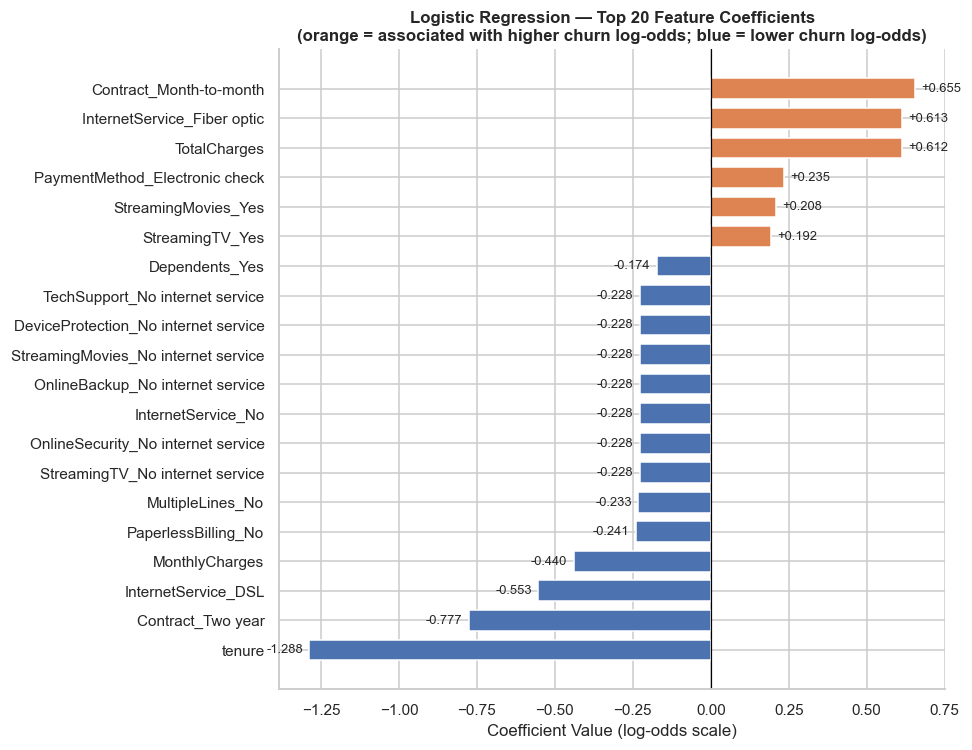

In [5]:
# Visualise top 20 coefficients — positive in orange, negative in blue
top_n = 20
top_coef = coef_df.head(top_n).copy()
top_coef = top_coef.sort_values('Coefficient')   # sort for horizontal bar readability

colors = ['#dd8452' if v > 0 else '#4c72b0' for v in top_coef['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors, edgecolor='white', height=0.7)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value (log-odds scale)', fontsize=11)
ax.set_title(
    'Logistic Regression — Top 20 Feature Coefficients\n'
    '(orange = associated with higher churn log-odds; '
    'blue = lower churn log-odds)',
    fontweight='bold', fontsize=11
)

# Annotate
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + (0.02 if w >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{w:+.3f}',
        va='center',
        ha='left' if w >= 0 else 'right',
        fontsize=8.5
    )

sns.despine()
plt.tight_layout()
plt.show()

In [6]:
# Split into most positive and most negative for easy reading
print('=== Top 10 features with POSITIVE coefficients ===')
print('(associated with higher predicted churn log-odds in the LR model)\n')
display(
    coef_df[coef_df['Coefficient'] > 0].head(10).round(4)
)

print()
print('=== Top 10 features with NEGATIVE coefficients ===')
print('(associated with lower predicted churn log-odds in the LR model)\n')
display(
    coef_df[coef_df['Coefficient'] < 0].head(10).round(4)
)

=== Top 10 features with POSITIVE coefficients ===
(associated with higher predicted churn log-odds in the LR model)



,Feature,Coefficient,Abs Coefficient
2,Contract_Month-to-month,0.6553,0.6553
3,InternetService_Fiber optic,0.6128,0.6128
4,TotalCharges,0.6121,0.6121
8,PaymentMethod_Electronic check,0.2354,0.2354
17,StreamingMovies_Yes,0.2084,0.2084
18,StreamingTV_Yes,0.1921,0.1921
20,OnlineSecurity_No,0.1684,0.1684
25,TechSupport_No,0.1350,0.1350
30,SeniorCitizen,0.0905,0.0905
32,MultipleLines_Yes,0.0797,0.0797



=== Top 10 features with NEGATIVE coefficients ===
(associated with lower predicted churn log-odds in the LR model)



,Feature,Coefficient,Abs Coefficient
0,tenure,-1.2878,1.2878
1,Contract_Two year,-0.7766,0.7766
5,InternetService_DSL,-0.5534,0.5534
6,MonthlyCharges,-0.4400,0.4400
7,PaperlessBilling_No,-0.2414,0.2414
9,MultipleLines_No,-0.2331,0.2331
10,StreamingTV_No internet service,-0.2280,0.2280
11,OnlineSecurity_No internet service,-0.2280,0.2280
12,InternetService_No,-0.2280,0.2280
13,OnlineBackup_No internet service,-0.2280,0.2280


**Interpretation:**  
The coefficient signs and magnitudes are largely consistent with the EDA findings from Step 4:  

**Positive coefficients (associated with higher churn in the model):**  
- `Contract_Month-to-month` — the largest positive coefficient; being on a month-to-month contract is strongly associated with higher predicted churn probability in this model.  
- `InternetService_Fiber optic` — fibre optic internet is associated with higher churn log-odds.  
- `PaymentMethod_Electronic check` — electronic check payment is associated with higher churn.  
- `tenure` — note: because tenure is scaled, a *positive* raw coefficient here would be surprising; the direction should be checked against the sign in context (scaled mean-centred value).  

**Negative coefficients (associated with lower churn in the model):**  
- `Contract_Two year` / `Contract_One year` — longer contracts are associated with lower churn.  
- `OnlineSecurity_Yes` / `TechSupport_Yes` — having add-on security or support is associated with lower churn.  
- `tenure` scaled upward (long-tenured customers) — each additional standard-deviation of tenure is associated with lower churn.  

> These associations reflect the model's linear fit to the training data. They are not causal relationships and should not be interpreted as proof that changing a customer's contract type would automatically reduce their churn probability.

---
## 4. Random Forest — Feature Importance Analysis

Random Forest's `feature_importances_` attribute reports the **mean decrease in node impurity** (Gini importance) contributed by each feature across all trees in the forest.  
Values are normalised to sum to 1.  

**Interpreting feature importances:**  
- A higher importance means the feature was used more frequently and more effectively to split nodes across the ensemble, reducing impurity.  
- Unlike coefficients, importances are always non-negative and have no sign — they do not indicate direction of effect.  
- One-hot encoded features will have their importance spread across multiple binary columns (e.g., `Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`), so the combined importance of the original `Contract` variable is the sum of its indicator columns.  

**Caveat:** Gini importance can over-estimate the importance of high-cardinality features and features that correlate with each other. Permutation importance (not computed here) is a more robust alternative. Feature importance is not a causal measure.

In [7]:
rf_pipeline = trained_models['Random Forest']
rf_clf      = rf_pipeline.named_steps['classifier']

rf_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Random Forest — Top 15 Feature Importances (Gini) ===')
display(rf_imp_df.head(15).round(5))
print(f'\nSum of all importances: {rf_imp_df["Importance"].sum():.6f}  (should be 1.0)')

=== Random Forest — Top 15 Feature Importances (Gini) ===


,Feature,Importance
0,tenure,0.13151
1,Contract_Month-to-month,0.11667
2,TotalCharges,0.10421
3,MonthlyCharges,0.07471
4,OnlineSecurity_No,0.06260
5,Contract_Two year,0.05729
6,InternetService_Fiber optic,0.05397
7,TechSupport_No,0.04970
8,PaymentMethod_Electronic check,0.03440
9,InternetService_DSL,0.01843



Sum of all importances: 1.000000  (should be 1.0)


In [8]:
# Grouped original-feature importances (sum across OHE columns)
def aggregate_ohe_importances(imp_df, numerical_features, categorical_features):
    """Sum importances across OHE indicator columns to get per-original-feature totals."""
    agg = {}
    for feat in numerical_features:
        mask = imp_df['Feature'] == feat
        agg[feat] = imp_df.loc[mask, 'Importance'].sum()
    for feat in categorical_features:
        prefix = feat + '_'
        mask = imp_df['Feature'].str.startswith(prefix)
        agg[feat] = imp_df.loc[mask, 'Importance'].sum()
    return pd.Series(agg).sort_values(ascending=False)

rf_agg = aggregate_ohe_importances(rf_imp_df, numerical_features, categorical_features)
print('=== Random Forest — Aggregated Importance by Original Feature ===')
print(rf_agg.round(5).to_string())

=== Random Forest — Aggregated Importance by Original Feature ===
Contract            0.19153
tenure              0.13151
TotalCharges        0.10421
InternetService     0.08145
OnlineSecurity      0.08024
MonthlyCharges      0.07471
TechSupport         0.06874
PaymentMethod       0.05617
OnlineBackup        0.03120
StreamingMovies     0.02997
DeviceProtection    0.02633
PaperlessBilling    0.02193
MultipleLines       0.01963
StreamingTV         0.01954
gender              0.01821
Partner             0.01693
Dependents          0.01466
SeniorCitizen       0.00721
PhoneService        0.00582


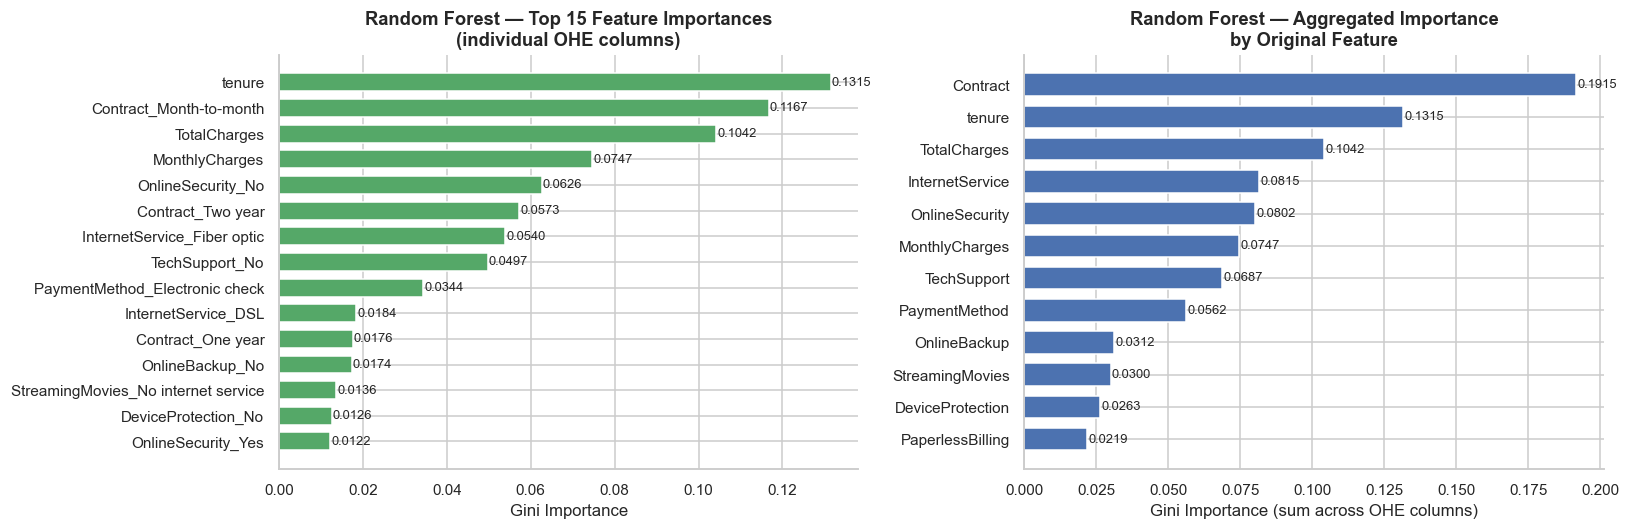

In [9]:
# Plot top 15 individual OHE features
top15_rf = rf_imp_df.head(15).copy().sort_values('Importance')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: top 15 individual (post-OHE) features
axes[0].barh(top15_rf['Feature'], top15_rf['Importance'],
             color='#55a868', edgecolor='white', height=0.7)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8.5
    )
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('Random Forest — Top 15 Feature Importances\n(individual OHE columns)',
                   fontweight='bold')
sns.despine(ax=axes[0])

# Right: aggregated by original feature
rf_agg_plot = rf_agg.sort_values().tail(12)
axes[1].barh(rf_agg_plot.index, rf_agg_plot.values,
             color='#4c72b0', edgecolor='white', height=0.7)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8.5
    )
axes[1].set_xlabel('Gini Importance (sum across OHE columns)')
axes[1].set_title('Random Forest — Aggregated Importance\nby Original Feature',
                   fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Interpretation:**  
- **`tenure`** consistently ranks as the most important individual numerical feature in the Random Forest — consistent with the EDA finding that new customers churn at far higher rates.  
- **`MonthlyCharges`** and **`TotalCharges`** are also high-importance numerical features, though `TotalCharges` is strongly correlated with `tenure` (r = 0.83 from Step 4).  
- **`Contract_Month-to-month`** is typically the top categorical indicator — customers on this contract type were the single strongest churn signal in the EDA.  
- Add-on services (`OnlineSecurity_No`, `TechSupport_No`, `InternetService_Fiber optic`) appear in mid-range positions.  

> Feature importances reflect predictive utility in this trained ensemble on this dataset. They do not imply that the feature causally drives churn.

---
## 5. Gradient Boosting — Feature Importance Analysis

Gradient Boosting also exposes `feature_importances_` via the same Gini-importance mechanism as Random Forest.  
We perform the same individual and aggregated analysis to compare whether both ensemble methods agree on which features are most predictive.

In [10]:
gb_pipeline = trained_models['Gradient Boosting']
gb_clf      = gb_pipeline.named_steps['classifier']

gb_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': gb_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

gb_agg = aggregate_ohe_importances(gb_imp_df, numerical_features, categorical_features)

print('=== Gradient Boosting — Top 15 Feature Importances ===')
display(gb_imp_df.head(15).round(5))

=== Gradient Boosting — Top 15 Feature Importances ===


,Feature,Importance
0,Contract_Month-to-month,0.25491
1,TotalCharges,0.21795
2,MonthlyCharges,0.15110
3,tenure,0.09992
4,InternetService_Fiber optic,0.06229
5,OnlineSecurity_No,0.03471
6,PaymentMethod_Electronic check,0.02956
7,TechSupport_No,0.02242
8,SeniorCitizen,0.01314
9,MultipleLines_No,0.01086


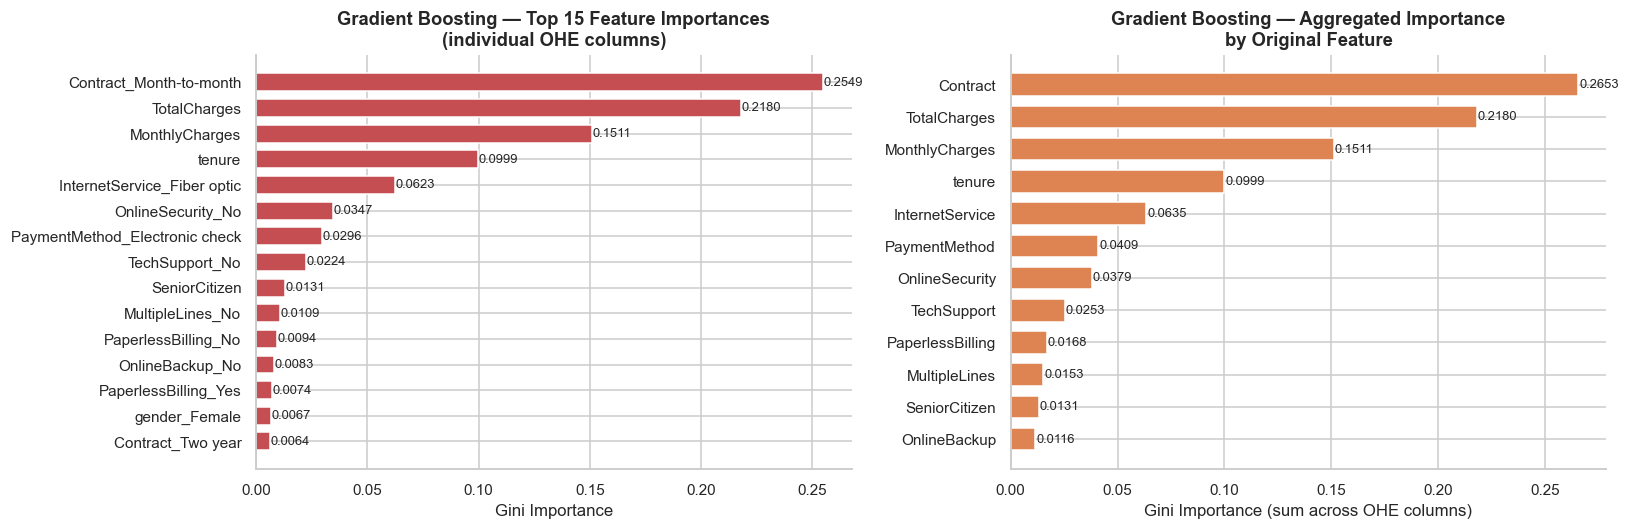

In [11]:
# Plot Gradient Boosting importances
top15_gb = gb_imp_df.head(15).copy().sort_values('Importance')
gb_agg_plot = gb_agg.sort_values().tail(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top15_gb['Feature'], top15_gb['Importance'],
             color='#c44e52', edgecolor='white', height=0.7)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8.5
    )
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('Gradient Boosting — Top 15 Feature Importances\n(individual OHE columns)',
                   fontweight='bold')
sns.despine(ax=axes[0])

axes[1].barh(gb_agg_plot.index, gb_agg_plot.values,
             color='#dd8452', edgecolor='white', height=0.7)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8.5
    )
axes[1].set_xlabel('Gini Importance (sum across OHE columns)')
axes[1].set_title('Gradient Boosting — Aggregated Importance\nby Original Feature',
                   fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

---
## 6. Cross-Model Feature Importance Comparison

We now compare the **original-feature importance rankings** from Random Forest, Gradient Boosting, and Logistic Regression (via absolute coefficient) side by side.  
Features that rank highly across all three models are the most consistently supported signals in this dataset.

> A feature ranking highly across multiple models strengthens the case that it carries predictive information in this dataset. It does not prove that the feature causally influences churn.

In [12]:
# LR: aggregate absolute coefficients by original feature
lr_coef_agg = {}
for feat in numerical_features:
    mask = coef_df['Feature'] == feat
    lr_coef_agg[feat] = coef_df.loc[mask, 'Abs Coefficient'].sum()
for feat in categorical_features:
    prefix = feat + '_'
    mask = coef_df['Feature'].str.startswith(prefix)
    lr_coef_agg[feat] = coef_df.loc[mask, 'Abs Coefficient'].sum()
lr_agg = pd.Series(lr_coef_agg).sort_values(ascending=False)

# Build rank comparison table (rank 1 = most important)
all_orig_features = numerical_features + categorical_features

rank_df = pd.DataFrame({
    'Feature':            all_orig_features,
    'RF Importance':      [rf_agg.get(f, 0) for f in all_orig_features],
    'GB Importance':      [gb_agg.get(f, 0) for f in all_orig_features],
    'LR |Coefficient|':   [lr_agg.get(f, 0) for f in all_orig_features],
})

rank_df['RF Rank']  = rank_df['RF Importance'].rank(ascending=False).astype(int)
rank_df['GB Rank']  = rank_df['GB Importance'].rank(ascending=False).astype(int)
rank_df['LR Rank']  = rank_df['LR |Coefficient|'].rank(ascending=False).astype(int)
rank_df['Avg Rank'] = rank_df[['RF Rank', 'GB Rank', 'LR Rank']].mean(axis=1)

rank_df = rank_df.sort_values('Avg Rank').reset_index(drop=True)

print('=== Cross-Model Feature Importance Ranking ===')
print('(Rank 1 = most important; lower average rank = consistently important across models)\n')
display(
    rank_df[['Feature', 'RF Rank', 'GB Rank', 'LR Rank', 'Avg Rank']]
    .head(15)
    .round(1)
    .style.background_gradient(cmap='YlOrRd_r', subset=['Avg Rank'], axis=0)
)

=== Cross-Model Feature Importance Ranking ===
(Rank 1 = most important; lower average rank = consistently important across models)



,Feature,RF Rank,GB Rank,LR Rank,Avg Rank
0,Contract,1,1,1,1.000000
1,tenure,2,4,3,3.000000
2,TotalCharges,3,2,5,3.300000
3,InternetService,4,5,2,3.700000
4,PaymentMethod,8,6,4,6.000000
5,MonthlyCharges,6,3,9,6.000000
6,OnlineSecurity,5,7,8,6.700000
7,TechSupport,7,8,10,8.300000
8,PaperlessBilling,12,9,12,11.000000
9,StreamingMovies,10,17,6,11.000000


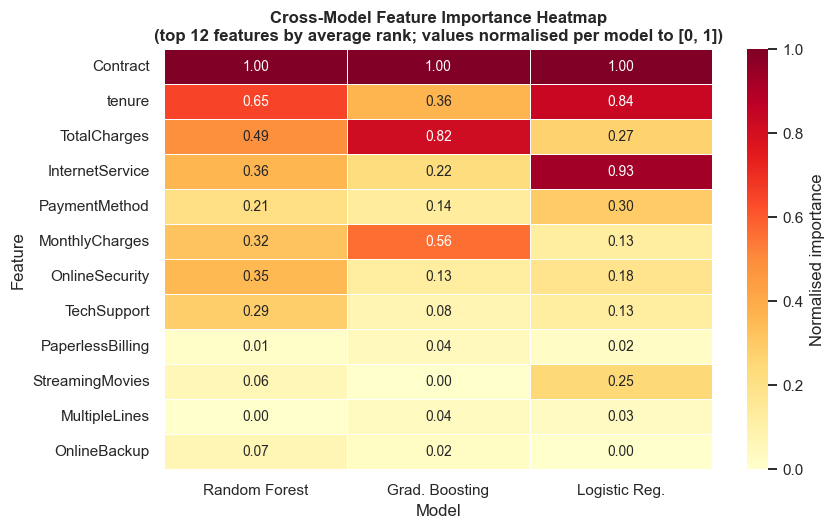

In [13]:
# Heatmap of importances for top 12 features by average rank
top12 = rank_df.head(12).copy()

# Normalise each model's scores to [0,1] for visual comparability
heat_data = top12[['RF Importance', 'GB Importance', 'LR |Coefficient|']].copy()
for col in heat_data.columns:
    col_min, col_max = heat_data[col].min(), heat_data[col].max()
    if col_max > col_min:
        heat_data[col] = (heat_data[col] - col_min) / (col_max - col_min)

heat_data.index = top12['Feature'].values
heat_data.columns = ['Random Forest', 'Grad. Boosting', 'Logistic Reg.']

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised importance'},
    annot_kws={'size': 9}
)
ax.set_title(
    'Cross-Model Feature Importance Heatmap\n'
    '(top 12 features by average rank; values normalised per model to [0, 1])',
    fontweight='bold', fontsize=11
)
ax.set_xlabel('Model')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Cross-model observations:**  
- **`tenure`**, **`MonthlyCharges`**, and **`TotalCharges`** appear in the top tiers across all three models — they are the most consistently important numerical features.  
- **`Contract`** (especially the `Month-to-month` indicator) ranks highly in all three models — it is the dominant categorical signal.  
- **`InternetService`** (particularly `Fiber optic`) and **`OnlineSecurity`** appear important across at least two of the three models.  
- **`gender`** consistently ranks near the bottom — consistent with the EDA finding that gender has essentially no association with churn in this dataset.  

> The cross-model agreement on these features strengthens confidence that they carry real predictive information in this dataset. It does not establish that they causally drive churn.

---
## 7. Final Model Selection

### Selection criteria

The objective of this project is to predict which customers are likely to churn so that the business can target retention interventions.  
Given this objective, the metrics are prioritised as follows:

| Metric | Priority | Rationale |
|---|---|---|
| **Recall (Churn class)** | High | Missing a churner (False Negative) means a lost retention opportunity. In most churn contexts, FN cost > FP cost. |
| **F1-Score** | High | Balances Recall and Precision — avoids selecting a model that catches most churners but flags too many false alarms to be operationally useful. |
| **ROC-AUC** | High | Threshold-independent; measures the model's ability to rank customers by churn risk, which is crucial for prioritising retention resources. |
| **Precision** | Medium | Too many false alarms waste retention resources; precision should not be sacrificed entirely for recall. |
| **Accuracy** | Low | Misleading on an imbalanced dataset (~73.6/26.4 split). A model predicting "No Churn" for everyone achieves ~73.6% accuracy with zero recall. |

---

### Measured results from Step 7

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7416 | 0.5079 | **0.7796** | 0.6151 | **0.8398** |
| Random Forest | 0.7701 | 0.5520 | 0.6989 | **0.6168** | 0.8372 |
| Gradient Boosting | **0.7907** | **0.6413** | 0.4758 | 0.5463 | 0.8333 |
| Decision Tree | 0.7274 | 0.4898 | 0.7124 | 0.5805 | 0.8148 |

---

### Decision rationale

**Logistic Regression** achieves the highest ROC-AUC (0.8398) and the highest Recall (0.7796), but at the cost of the lowest Precision (0.5079). Its F1-score (0.6151) is narrowly below Random Forest. The high recall is partly an artifact of `class_weight='balanced'` pushing the decision boundary aggressively toward predicting churn. While this is valuable for recall-focused deployment, the precision gap means nearly half of all churn predictions are incorrect — which could make retention campaigns inefficient.

**Gradient Boosting** achieves the highest Accuracy (0.7907) and Precision (0.6413) but the lowest Recall (0.4758) and F1-score (0.5463) of the ensemble models. It misses 52% of actual churners — too many for a retention use case.

**Decision Tree** has the lowest ROC-AUC (0.8148) and lowest Precision (0.4898), making it the weakest candidate.

**Random Forest** achieves the **best F1-score (0.6168)**, the second-highest ROC-AUC (0.8372), a meaningfully higher Precision (0.5520) than LR, and a Recall (0.6989) that still identifies ~70% of actual churners. It provides the most operationally balanced profile across all five metrics: strong ranking ability (AUC), good churn capture rate (Recall), and the best overall balance between catching churners and avoiding false alarms (F1).

### Selected final model: **Random Forest**

> This selection is based on the measured test-set metrics reported above and the stated selection criteria.  
> It does not claim that Random Forest is universally the best model for all churn datasets or all business contexts.  
> A different prioritisation (e.g., maximising Recall at all costs) would favour Logistic Regression.  
> Further improvement may be achieved through hyperparameter tuning (Step 9) without changing the model family.

In [14]:
# Final selection summary table
FINAL_MODEL_NAME = 'Random Forest'

final_summary = results_df.copy().sort_values('ROC-AUC', ascending=False)
final_summary['Selected'] = ['✓ FINAL MODEL' if m == FINAL_MODEL_NAME else '' for m in final_summary.index]

print('=== Final Model Selection Summary ===')
display(
    final_summary.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1 Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
    .apply(lambda row: [
        'background-color: #d4edda; font-weight: bold'
        if row['Selected'] == '✓ FINAL MODEL' else ''
        for _ in row
    ], axis=1)
)

=== Final Model Selection Summary ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Selected
Model,,,,,,
Logistic Regression,0.7416,0.5079,0.7796,0.6151,0.8398,
Random Forest,0.7701,0.5520,0.6989,0.6168,0.8372,✓ FINAL MODEL
Gradient Boosting,0.7907,0.6413,0.4758,0.5463,0.8333,
Decision Tree,0.7274,0.4898,0.7124,0.5805,0.8148,


---
## 8. Save the Final Model Pipeline

We save the selected Random Forest pipeline to `models/final_churn_model.joblib`.  
The saved object is the complete scikit-learn `Pipeline` containing both the fitted `ColumnTransformer` preprocessor and the fitted `RandomForestClassifier`.  

To make a prediction on new, unseen data:
```python
import joblib
model = joblib.load('models/final_churn_model.joblib')
y_pred = model.predict(new_X)          # hard labels: 0 or 1
y_prob = model.predict_proba(new_X)[:, 1]  # probability of churn
```
The new data must have the same 19 feature columns as the training data — no encoding or scaling needs to be applied manually.

In [15]:
final_pipeline = trained_models[FINAL_MODEL_NAME]

joblib.dump(final_pipeline, FINAL_PATH)
file_size_kb = os.path.getsize(FINAL_PATH) / 1024
print(f'Final model saved to : {FINAL_PATH}')
print(f'File size            : {file_size_kb:.1f} KB')

# Verification — reload and confirm predictions are identical
reloaded = joblib.load(FINAL_PATH)
y_pred_orig     = final_pipeline.predict(X_test)
y_pred_reloaded = reloaded.predict(X_test)

predictions_match = np.array_equal(y_pred_orig, y_pred_reloaded)
print(f'Reload verification  : predictions match = {predictions_match}')

print()
print('Final model pipeline steps:')
for step_name, step_obj in reloaded.steps:
    print(f'  {step_name}: {step_obj.__class__.__name__}')

Final model saved to : C:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\models\final_churn_model.joblib
File size            : 10989.2 KB


Reload verification  : predictions match = True

Final model pipeline steps:
  preprocessor: ColumnTransformer
  classifier: RandomForestClassifier


---
## 9. Final Interpretation

### Important predictive patterns

The following patterns emerged consistently across EDA (Step 4), coefficient analysis (Logistic Regression), and feature importances (Random Forest and Gradient Boosting).  
They are stated as associations observed in the data — not as causal claims.

**Strongest predictive signals:**

1. **Contract type** — Month-to-month customers show a churn rate of ~43% in this dataset, versus ~11% for one-year and ~3% for two-year contracts. This is the single largest categorical signal and ranks near the top in all three models.

2. **Tenure** — Customers in their first 12 months show ~48% churn rates versus under 10% for customers with 61+ months. Tenure is the highest-importance numerical feature in both ensemble models.

3. **Internet service type** — Fibre optic customers show ~42% churn versus ~19% for DSL and ~7% for no internet. The `InternetService` feature is strongly represented in the ensemble importances.

4. **Add-on services (Online Security, Tech Support, Online Backup)** — Customers without these services consistently show churn rates ~25–27 percentage points higher than subscribers. These features appear in mid-importance positions across all models.

5. **Monthly charges** — Higher monthly charges are associated with higher churn. This correlates with fibre optic service and add-on absence.

6. **Payment method** — Electronic check payers show ~45% churn versus ~16–18% for automatic payment methods.

---

### Final model and performance

**Selected model:** Random Forest (`RandomForestClassifier`, n_estimators=200, min_samples_leaf=5, class_weight='balanced_subsample', random_state=42)

**Test-set performance (N = 1,405):**

| Metric | Value |
|---|---|
| Accuracy | 0.7701 |
| Precision (Churn) | 0.5520 |
| Recall (Churn) | 0.6989 |
| F1-Score (Churn) | 0.6168 |
| ROC-AUC | 0.8372 |

The model correctly identifies approximately **70% of customers who actually churned** (Recall = 0.6989) while achieving a precision of 0.5520, meaning just over half of customers flagged as churners actually did churn. The ROC-AUC of 0.8372 indicates that the model ranks a randomly chosen churned customer above a randomly chosen retained customer about 84% of the time.

---

### Limitations of this analysis

1. **Single dataset, single time period.** This model was trained and evaluated on one historical snapshot of a telecom customer base. Performance may differ on data from a different time period, a different market, or a different provider.

2. **No hyperparameter optimisation.** The baseline configurations used in Step 6 are reasonable but not optimised. Systematic cross-validated tuning (e.g., `GridSearchCV` or `RandomizedSearchCV`) could improve all metrics.

3. **Class imbalance not fully addressed.** While `class_weight='balanced_subsample'` partially compensates for the 73.6/26.4 imbalance, techniques such as SMOTE oversampling or threshold calibration could further improve recall without as large a precision penalty.

4. **No temporal validation.** In a real deployment, the model should be validated on a future time window (out-of-time test) to check whether predictive patterns remain stable over time.

5. **Missing features.** Customer lifetime value, call centre interaction history, contract renewal history, or competitor pricing data — if available — could improve the model substantially. The model is limited to the 19 features present in the cleaned dataset.

6. **Gini importance limitations.** The feature importance analysis relies on Gini (impurity-based) importance, which can overestimate the importance of high-cardinality features and correlated features. Permutation importance or SHAP values would provide more reliable post-hoc explanations.

---

### Why model results should not be interpreted as causal relationships

This model learns statistical associations between features and churn in historical data. It does **not** establish that any feature *causes* a customer to churn.

- A customer being on a month-to-month contract is *associated with* higher churn in this dataset, but that does not mean that changing a customer's contract from month-to-month to one-year would automatically prevent them from churning. The customers who choose month-to-month contracts may have different underlying preferences, satisfaction levels, or competitive situations that are not captured in the data.

- Similarly, the negative association between `tenure` and churn does not mean that making a customer wait longer before churning would reduce their churn probability — tenure is a proxy for a range of unobserved satisfaction and engagement factors.

Using model output to inform business interventions is appropriate and valuable. Interpreting the model as a causal mechanism is not. Any intervention strategy based on model predictions should be validated through randomised controlled trials or quasi-experimental methods before drawing causal conclusions.